# RQ2 — Implementation Practices (Q17–Q20)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
print(f"N={len(df)}")


N=56


In [2]:
Q17_OPTIONS = U.Q17_OPTIONS
Q17_LABELS  = dict(U.Q17_LABELS)
Q18_OPTIONS = U.Q18_OPTIONS
Q18_LABELS  = dict(U.Q18_LABELS)
Q20_OPTIONS = U.Q20_OPTIONS
Q20_LABELS  = dict(U.Q20_LABELS)

In [3]:
q17_bin, q17_res = U.parse_checkboxes(df["incorporation_open"], Q17_OPTIONS)
q18_bin, q18_res = U.parse_checkboxes(df["measurement_open"], Q18_OPTIONS)
q20_bin, q20_res = U.parse_checkboxes(df["documentation_open"], Q20_OPTIONS)

n_q17 = df["incorporation_open"].notna().sum()
n_q18 = df["measurement_open"].notna().sum()
n_q20 = df["documentation_open"].notna().sum()

for q, name, n in [(q17_bin, "Q17", n_q17), (q18_bin, "Q18", n_q18), (q20_bin, "Q20", n_q20)]:
    print(f"{name}: n={n}, average options marked = {q.sum(axis=1).mean():.2f}")

q17_bin["q17_other"] = q17_res.str.len() > 0
q18_bin["q18_other"] = q18_res.str.len() > 0
q20_bin["q20_other"] = q20_res.str.len() > 0

Q17_LABELS["q17_other"] = "Other"
Q18_LABELS["q18_other"] = "Other"
Q20_LABELS["q20_other"] = "Other"

Q17: n=56, average options marked = 1.93
Q18: n=56, average options marked = 1.73
Q20: n=56, average options marked = 2.16


In [4]:
q19_bin = pd.DataFrame({
    "q19_never":     df["discussion_freq"] == 1,
    "q19_rarely":    df["discussion_freq"] == 2,
    "q19_sometimes": df["discussion_freq"] == 3,
    "q19_often":     df["discussion_freq"] == 4,
    "q19_always":    df["discussion_freq"] == 5,
})
n_q19 = df["discussion_freq"].notna().sum()

p17 = U.proportions_with_ci(q17_bin, Q17_LABELS, n_q17)
p18 = U.proportions_with_ci(q18_bin, Q18_LABELS, n_q18)
p19 = U.proportions_with_ci(q19_bin, U.Q19_LABELS, n_q19)
p20 = U.proportions_with_ci(q20_bin, Q20_LABELS, n_q20)

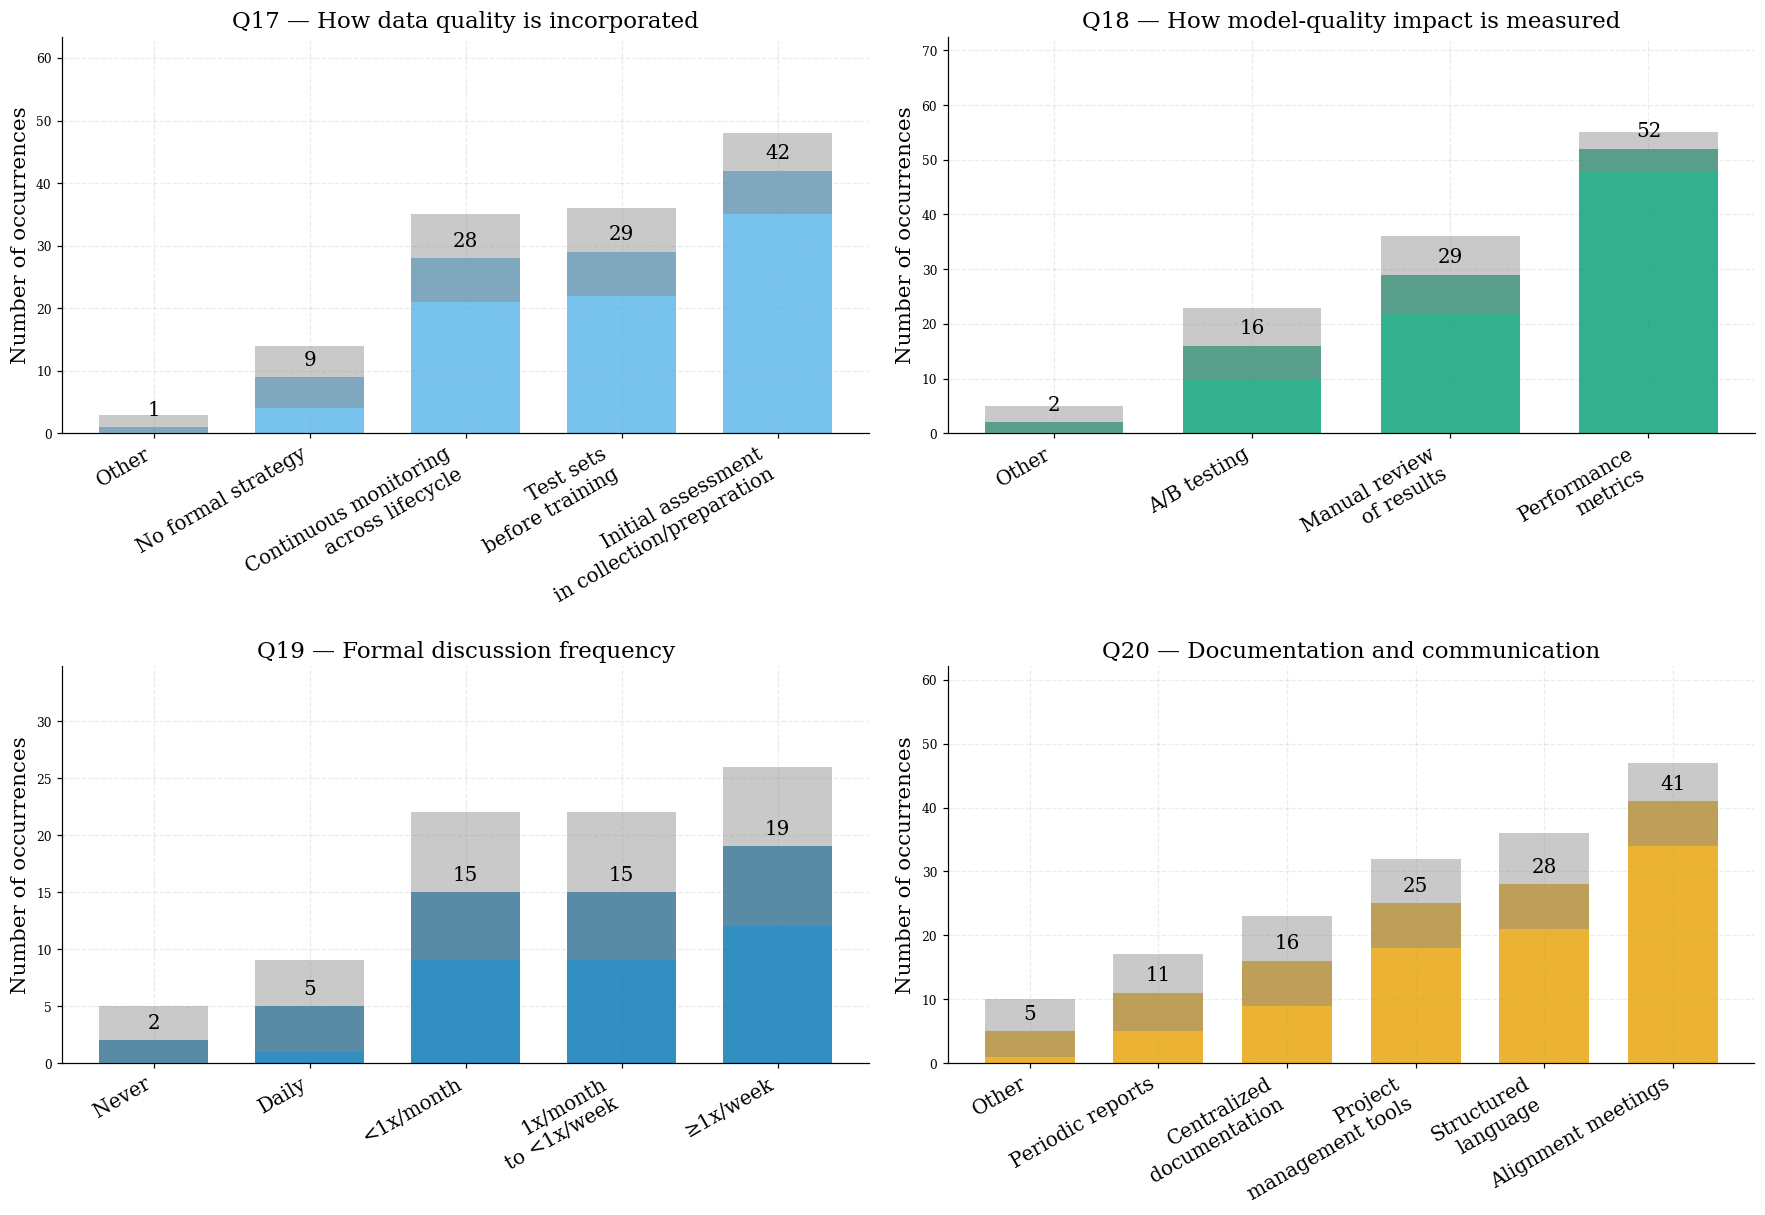

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

U.ci_band_barv_plot(p17, "Q17 — How data quality is incorporated",     U.PALETTE_WONG[2], axes[0, 0])
U.ci_band_barv_plot(p18, "Q18 — How model-quality impact is measured", U.PALETTE_WONG[3], axes[0, 1])
U.ci_band_barv_plot(p19, "Q19 — Formal discussion frequency",          U.PALETTE_WONG[5], axes[1, 0])
U.ci_band_barv_plot(p20, "Q20 — Documentation and communication",      U.PALETTE_WONG[1], axes[1, 1])

fig.tight_layout(pad=0.6, h_pad=2.5, w_pad=2.0)
U.save_fig(fig, "implementation_q17_q20")
plt.show()

In [6]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans", "Helvetica"],
})

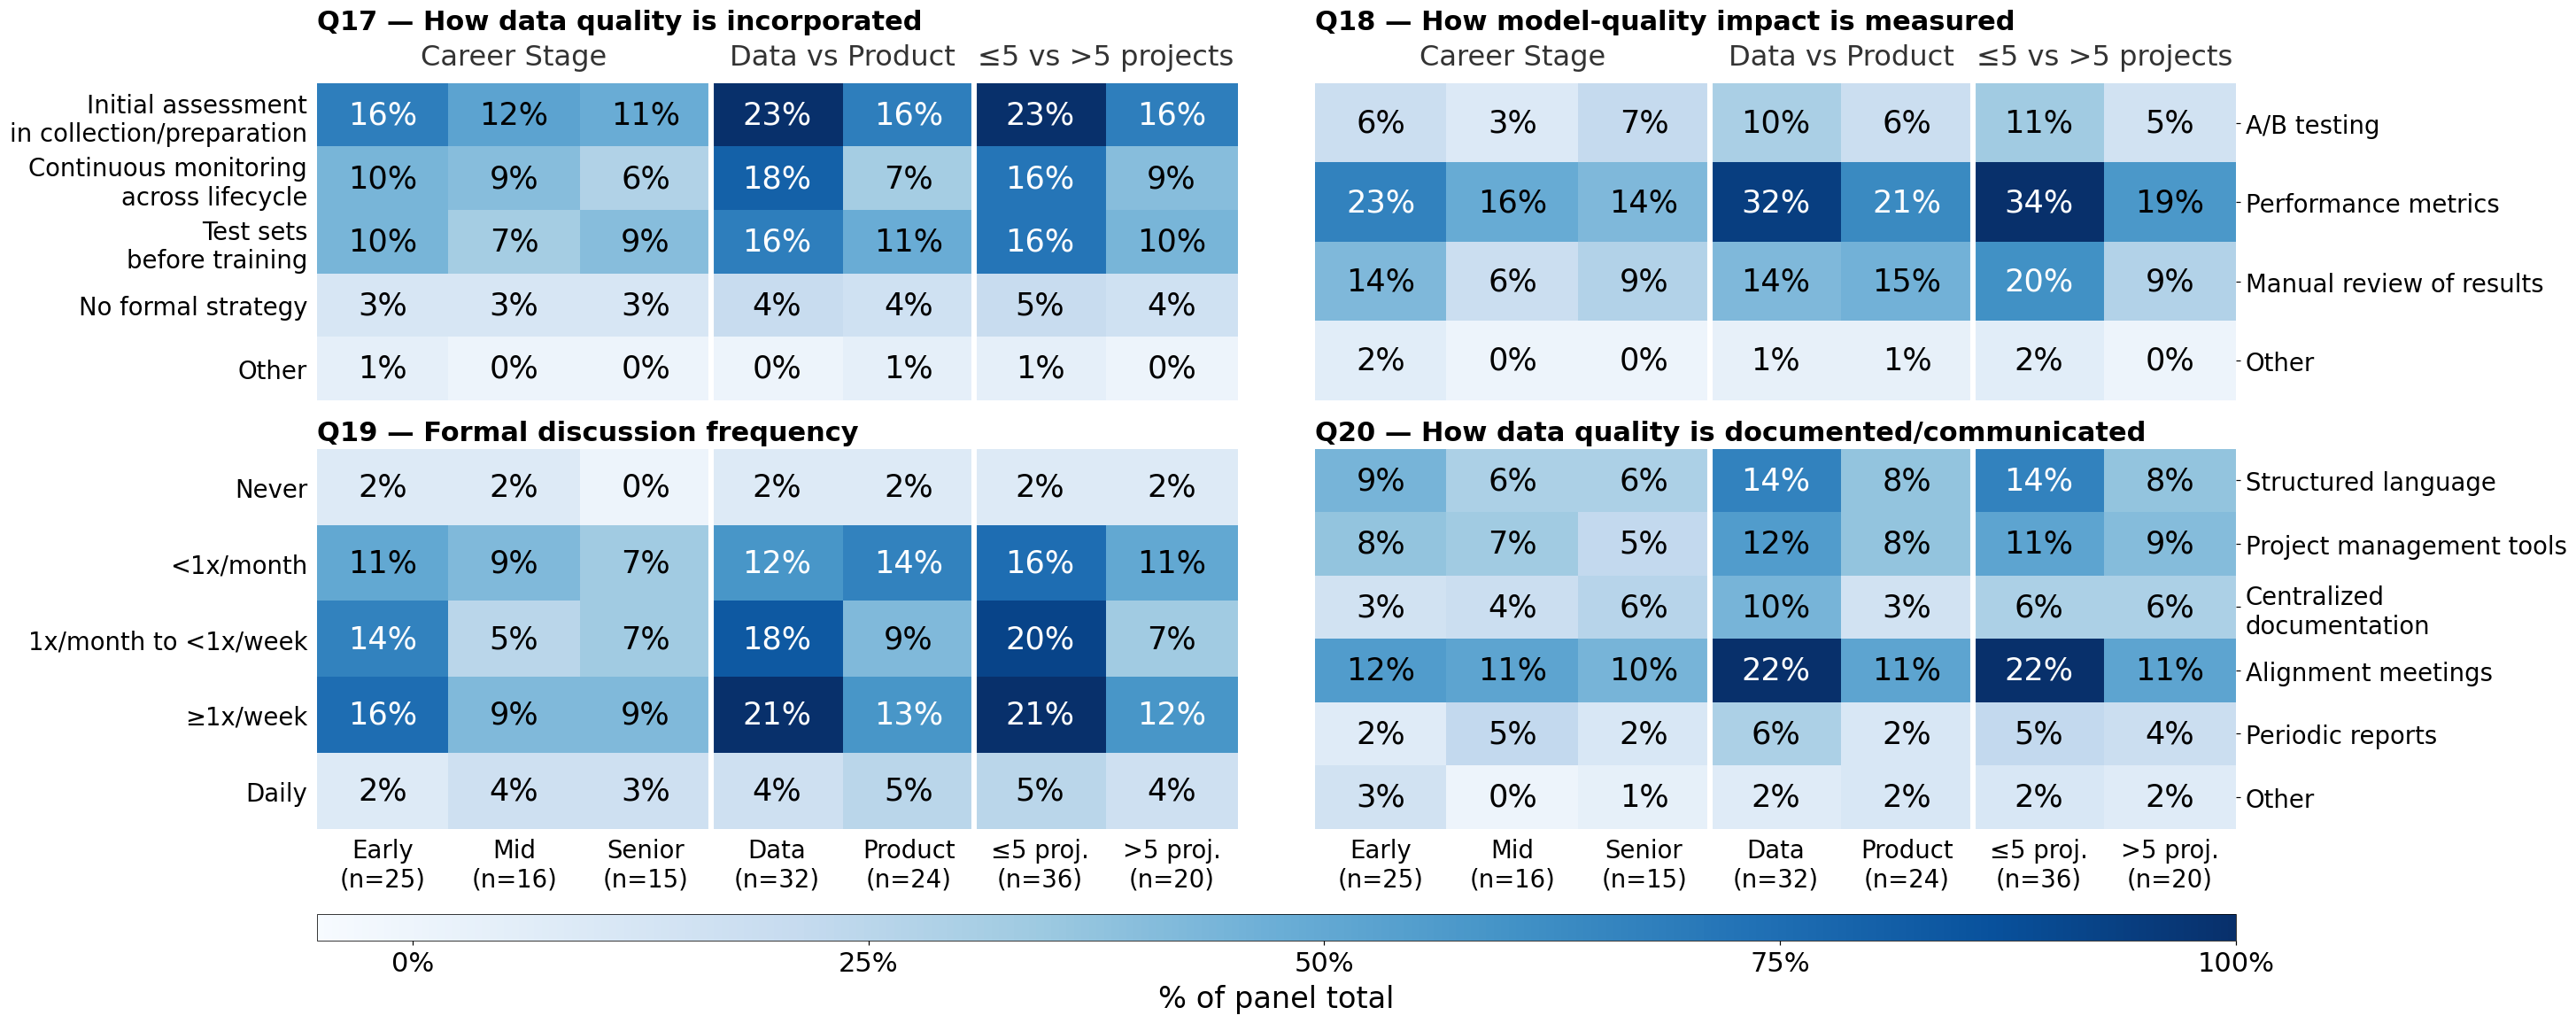

In [7]:
q19_bin = pd.DataFrame({
    "q19_never":     df["discussion_freq"] == 1,
    "q19_rarely":    df["discussion_freq"] == 2,
    "q19_sometimes": df["discussion_freq"] == 3,
    "q19_often":     df["discussion_freq"] == 4,
    "q19_always":    df["discussion_freq"] == 5,
})

comparisons_heatmap = [
    ("Career Stage", [
        ("Early",  df["seniority_norm"].isin(["Trainee", "Junior (up to 5 years)"])),
        ("Mid",    df["seniority_norm"] == "Full (6 to 9 years)"),
        ("Senior", df["seniority_norm"] == "Senior (10+ years)"),
    ]),
    ("Data vs Product", [
        ("Data",    df["role_group"].isin(["Data Scientist", "Data Engineer", "ML Engineer"])),
        ("Product", df["role_group"].isin(["Developer", "Data and AI Manager", "Researcher", "DevOps Engineer", "Tech manager", "Product owner", "Other"])),
    ]),
    ("≤5 vs >5 projects", [
        ("≤5 proj.", df["n_projects"] <= 5),
        (">5 proj.",      df["n_projects"] > 5),
    ]),
]

questions_heatmap = [
    ("Q17 — How data quality is incorporated",            q17_bin, Q17_LABELS, df["incorporation_open"]),
    ("Q18 — How model-quality impact is measured",        q18_bin, Q18_LABELS, df["measurement_open"]),
    ("Q19 — Formal discussion frequency",                 q19_bin, U.Q19_LABELS, df["discussion_freq"]),
    ("Q20 — How data quality is documented/communicated", q20_bin, Q20_LABELS, df["documentation_open"]),
]

fig_hm = U.four_question_heatmaps_2x2(questions_heatmap, comparisons_heatmap)
U.save_fig(fig_hm, "mc_group_heatmap_2x2")
plt.show()